<a href="https://colab.research.google.com/github/samaalamlki/SilentGuard/blob/main/text_classification_project.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **Phase 1 : Data Loading**

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

data_fake = pd.read_csv("D:/NLP Text data/Fake.csv")
data_true = pd.read_csv("D:/NLP Text data/True.csv")

In [ ]:
print(data_fake.columns)
print(data_true.columns)

Index(['title', 'text', 'subject', 'date'], dtype='object')
Index(['title', 'text', 'subject', 'date'], dtype='object')


In [ ]:
data_fake['class'] = "fake"
data_true['class'] = "true"

In [ ]:
data_full = pd.concat([data_fake,data_true],axis=0)

In [ ]:
data = data_full.sample(frac=1, random_state=42).reset_index(drop=True)

In [ ]:
data = data.drop(['date'],axis=1)
print(data.columns)

Index(['title', 'text', 'subject', 'class'], dtype='object')


In [ ]:
data = data.drop(['subject'],axis=1)
print(data.columns)

Index(['title', 'text', 'class'], dtype='object')


In [ ]:
def combine_text_columns(title,text):

    full_new = title + "\n" + text

    return full_new


data["full_new"] = data[['title', 'text']].apply(
    lambda row: combine_text_columns(row['title'], row['text']),axis=1)

In [ ]:
data = data.drop(['text','title'],axis=1)
print(data.columns)

Index(['class', 'full_new'], dtype='object')


# **Phase 2 : Data preprocessing**

In [ ]:
from nltk import word_tokenize, sent_tokenize, pos_tag , WordNetLemmatizer
from nltk.corpus import stopwords, wordnet
import string
import re

def get_pos(tag):
    if tag.startswith('J'):
        return wordnet.ADJ
    elif tag.startswith('V'):
        return wordnet.VERB
    elif tag.startswith('R'):
        return wordnet.ADV
    elif tag.startswith('N'):
        return wordnet.NOUN
    return wordnet.NOUN

def preprocessing_text(text):
    punctuations = set(string.punctuation)
    StopWords = set(stopwords.words('english'))
    lemmatizer = WordNetLemmatizer()

    text = re.sub(r"\s+"," ",text).strip()
    sentences = sent_tokenize(text)
    new_sentences = []
    for i in sentences :
        tokens = word_tokenize(i)
        tags = pos_tag(tokens)
        new_tokens = [ lemmatizer.lemmatize(word.lower(),get_pos(tag)) for word,tag in tags
                      if ( word not in StopWords) and ( word not in punctuations ) and (word.isdigit() == 0)]

        processed_sent = " ".join(new_tokens)
        new_sentences.append(processed_sent)

    return ".".join(new_sentences)

In [ ]:
data["clean_text"] = data['full_new'].apply(preprocessing_text)

In [ ]:
print(data.iloc[0,1])
print(data.iloc[0,2])

Ben Stein Calls Out 9th Circuit Court: Committed a ‘Coup d’état’ Against the Constitution
21st Century Wire says Ben Stein, reputable professor from, Pepperdine University (also of some Hollywood fame appearing in TV shows and films such as Ferris Bueller s Day Off) made some provocative statements on Judge Jeanine Pirro s show recently. While discussing the halt that was imposed on President Trump s Executive Order on travel. Stein referred to the judgement by the 9th Circuit Court in Washington state as a  Coup d tat against the executive branch and against the constitution.  Stein went on to call the Judges in Seattle  political puppets  and the judiciary  political pawns. Watch the interview below for the complete statements and note the stark contrast to the rhetoric of the leftist media and pundits who neglect to note that no court has ever blocked any Presidential orders in immigration in the past or discuss the legal efficacy of the halt or the actual text of the Executive Orde

# **Phase 3 : Convert to Numerical Data**

In [ ]:
from sklearn.feature_extraction.text import TfidfVectorizer

cv = TfidfVectorizer()
x = data.iloc[:1000,:]
x = cv.fit_transform(x['clean_text']).toarray()

print(x.shape)

(1000, 18508)


In [ ]:
from sklearn.preprocessing import LabelEncoder
y = data.iloc[:1000,:]
y = y['class']

label = LabelEncoder()
y = label.fit_transform(y)

print(len(y))

1000


# **Phase 4 : train_test_split**

In [ ]:
from sklearn.model_selection import train_test_split

x_train , x_test , y_train , y_test = train_test_split(x,y,train_size=0.8)

# **Phase 5 : Model Selection**

In [ ]:
from sklearn.naive_bayes import GaussianNB

model = GaussianNB()
model.fit(x_train,y_train)

,priors,None
,var_smoothing,1e-09


In [ ]:
from sklearn.metrics import classification_report

y_pred = model.predict(x_test)

print(classification_report(y_test,y_pred))


              precision    recall  f1-score   support

           0       0.74      0.87      0.80       103
           1       0.84      0.68      0.75        97

    accuracy                           0.78       200
   macro avg       0.79      0.78      0.78       200
weighted avg       0.79      0.78      0.78       200



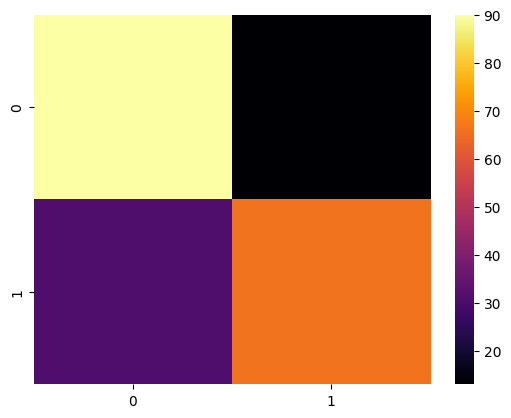

In [ ]:
from sklearn.metrics import confusion_matrix
import seaborn as sns

sns.heatmap(confusion_matrix(y_test,y_pred),cmap="inferno")
plt.show()